# Which early network signals of new topics travel? — RQ1 held-out demo

This notebook is a runnable walk-through of the **RQ1 held-out deliverable** (artifact `art_dFQ6jbgNsR6Q`, experiment 8).
The research question: *which temporal network indicators, measured in the first three years of a concept's life
(t0..t0+2), anticipate its later emergence — and do they keep working in scientific domains that were never used to pick them?*

**What the full experiment did** (12,499 TAG-grounded OpenAlex concepts):

1. Two zero-credit OpenAlex S3 passes (grounded works, authors, windowed citations).
2. **53 candidate indicators in 7 families** over t0..t0+2 — popularity **E**, disciplinary **F**, landing **G**,
   retained frontier **FR**, 27 co-occurrence ego-network measures **A**, co-author **S** — plus a 5-variable
   popularity/reach baseline **B5**.
3. Outcomes: `O1c`/`O1b` uptake, `O2r_m50`/`O2r_resid` disciplinary breadth, `O3` transience, `O4` citation growth,
   `O5`/`O5_WW` external recognition.
4. **DEV-only selection** on CS / Eng / BGM / Med: partial Spearman `psp(x, y | B5)` (continuous) or ΔAUC over B5
   (binary) with concept bootstraps, a frozen top-10 per outcome, learned ElasticNet / L1-logit / EBM models.
5. **Freeze + hash seal**, then a single unseal of the held-out domains (PHYS, LIFEENV, SOC, MATHDEC + a 2010-14
   cohort): frozen scoring, DerSimonian-Laird pooling across domains, Holm correction, sign agreement.

**Full-run headline:** breadth is predictable beyond B5 *and portable* — 7/10 (`O2r_m50`) and 8/10 (`O2r_resid`)
frozen indicators confirmed on held-out domains (e.g. `M0_density_end` psp +0.377, `D_vol_end` +0.307,
`CONTACT_REACH` +0.210); uptake (`O1c`) only via `n_authors_early`; external recognition (`O5`) not predictable beyond B5.

**What this demo runs.** The artifact's `method.py` is an orchestrator that launches 9 sub-scripts (the S3 passes
need ~100 GB of OpenAlex snapshot). Here we show that orchestrator, then run its *statistical core* — the code of
`lib/indicators.py`, `lib/rq1stats.py`, `lib/design.py`, `dev_select.py` and `heldout.py` — copied as closely as
possible on a **100-concept subset** of the per-concept indicator/outcome table (60 DEV concepts: 15 each from
CS/Eng/BGM/Med; 40 held-out: 20 PHYS + 20 SOC). With n=100 the numbers are noisy; the full-run values are printed
next to them for comparison.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# interpret-core (Explainable Boosting Machine) — NOT on Colab, always install
_pip('interpret-core==0.7.8')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# --- original imports (method.py, dev_select.py, heldout.py, lib/rq1stats.py) ---
import argparse
import hashlib
import json
import math
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata, spearmanr

# --- notebook additions ---
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_AawnV1HvzpNx/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["demo_subset"])
print("examples:", len(data["datasets"][0]["examples"]))

100 concepts, t0 in 2005-2007, complete O1c/O2r_m50/O2r_resid/O4/O1b: 60 DEV (15 each CS/Eng/BGM/Med) + 40 held-out (20 PHYS, 20 SOC); seed 20260928
examples: 100


## Configuration

All tunable parameters of the pipeline. The demo values are much smaller than the original ones (in comments) so
the notebook finishes in a few minutes on 100 concepts. Set them back to the original values for a full-size run
(which needs the full 12,499-concept table from `full_method_out.json`).

In [5]:
SEED = 20260928          # original seed (lib/common.py)

# dev_select.py
N_BOOT_CONT = 200        # concept-bootstrap resamples for psp on DEV            (original 1000)
N_BOOT_BIN = 20          # refit bootstraps for dAUC on DEV                       (original 500)
N_BOOT_SENS = 60         # bootstraps per placebo run                             (original 200)
N_PERM = 5               # shuffled-outcome placebo permutations (T5)             (original 20)
MAX_MISSING = 0.30       # max share missing for an indicator to be frozen        (original 0.30)
DEDUP_RHO = 0.85         # greedy |Spearman| dedup threshold                      (original 0.85)
TOP_K = 10               # frozen top-k per outcome                               (original 10)
MIN_DEV_ROWS = 40        # min non-missing DEV outcome values to rank an outcome  (original 100)
N_JOBS = 1               # sklearn n_jobs                                         (original 5)
ENET_N_ALPHAS = 100      # alphas on the ElasticNetCV path                        (original: sklearn default 100)
RUN_EBM = True           # fit the Explainable Boosting Machine (original: True). ~1 s/fit on Colab; minutes on a busy CPU
EBM_OUTER_BAGS = 8       # EBM outer bags                                         (original 8)
EBM_INTERACTIONS = 10    # EBM pairwise interactions                              (original 10)

# heldout.py
B_HELD = 200             # bootstraps for frozen held-out scoring                 (original 1000)
B_LEARNED = 200          # paired bootstraps learned-vs-B5 on held-out            (original 500)
MIN_POS = 5              # min positives/negatives per held-out unit (binary)     (original 20)
MIN_UNIT_ROWS = 15       # min rows per held-out unit for learned-model scoring   (original 30)

## 1. The orchestrator (`method.py`)

The original `method.py` runs 9 idempotent steps as subprocesses, each skipped if its output marker exists.
Steps 0-4 (unit tests, the two OpenAlex S3 passes, feature building, outcome construction) need the raw snapshot and
are **not re-run here** — their product is the per-concept indicator + outcome table that `mini_demo_data.json`
contains. The only change: `subprocess.run` is replaced by a dry-run `print` so you can see the exact command plan.
Steps 5-6 (`dev_select.py`, `heldout.py`) are then executed in-notebook in the cells below.

In [6]:
ROOT = Path(".")
DATA, RES, LOGS = ROOT / "data", ROOT / "results", ROOT / "logs"

PY = sys.executable
STEPS = [
    ("tests", [["tests/test_units.py"], ["tests/t0_8_ego_port.py"]], RES / "t0_8_ego_port.json"),
    ("passA", [["passA.py", "--workers", "{w}"], ["passA.py", "--merge"]], DATA / "passA_info.json"),
    ("passB", [["passB.py", "--workers", "{w}"], ["passB.py", "--merge"]], DATA / "passB_info.json"),
    ("features", [["build_features.py", "--stage", "all", "--workers", "{w}"]], RES / "indicator_matrix.parquet"),
    ("outcomes", [["outcomes.py"]], DATA / "outcomes_sealed.parquet"),
    ("dev_select", [["dev_select.py", "--stage", "all", "--workers", "{w}"]], LOGS / "seal.log"),
    ("heldout", [["heldout.py", "--stage", "all", "--workers", "{w}"]], RES / "sensitivities_pooled.json"),
    ("audit", [["audit.py"]], RES / "audit.json"),
    ("outputs", [["make_outputs.py"]], RES / "rq1_heldout.json"),
]


def main(start=None, only=None, workers=5, dry_run=True) -> None:
    names = [s[0] for s in STEPS]
    i0 = names.index(start) if start else 0
    for name, cmds, marker in STEPS[i0:]:
        if only and name != only:
            continue
        if marker.exists() and not (only or start == name):
            print(f"skip {name}: {marker.relative_to(ROOT)} exists")
            continue
        for c in cmds:
            cmd = [PY] + [x.format(w=workers) for x in c]
            if dry_run:   # notebook: show the plan instead of launching the sub-script
                print(f"[{name:10s}] would run: {' '.join(c).format(w=workers):55s} -> marker {marker}")
                continue
            t = time.time()
            r = subprocess.run(cmd, cwd=ROOT)
            if r.returncode != 0:
                raise SystemExit(f"step {name} failed ({' '.join(c)}), exit {r.returncode}")
            print(f"done {' '.join(c)} in {(time.time()-t)/60:.1f} min")


main()

[tests     ] would run: tests/test_units.py                                     -> marker results/t0_8_ego_port.json
[tests     ] would run: tests/t0_8_ego_port.py                                  -> marker results/t0_8_ego_port.json
[passA     ] would run: passA.py --workers 5                                    -> marker data/passA_info.json
[passA     ] would run: passA.py --merge                                        -> marker data/passA_info.json
[passB     ] would run: passB.py --workers 5                                    -> marker data/passB_info.json
[passB     ] would run: passB.py --merge                                        -> marker data/passB_info.json
[features  ] would run: build_features.py --stage all --workers 5               -> marker results/indicator_matrix.parquet
[outcomes  ] would run: outcomes.py                                             -> marker data/outcomes_sealed.parquet
[dev_select] would run: dev_select.py --stage all --workers 5                   

## 2. The indicator dictionary (`lib/indicators.py`, verbatim)

53 candidate indicators in 7 families, all measured over the window t0..t0+2, plus the **B5 baseline**
(log volume, growth, off-home share, disciplinary entropy, reach). Every indicator is judged by what it adds
*beyond* B5 — so a measure that is merely a proxy for "the concept is getting popular" scores zero.
Outcomes: 4 continuous (`O1c` uptake, `O2r_m50` / `O2r_resid` breadth, `O4` citation growth) and 4 binary
(`O1b` uptake, `O3` transience, `O5` / `O5_WW` external recognition).

In [7]:
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]

FAMILIES: dict[str, list[tuple[str, str]]] = {
    "E": [("share", "grounded works t0..t0+2 per million base works (EXP5)"),
          ("growth_ind", "log((N_t0+2 + 1)/(N_t0+1 + 1)) (EXP5)"),
          ("accel", "quadratic coefficient of log1p(N) over t0..t0+2 (EXP5)"),
          ("burst", "Kleinberg 2-state burst weight t0-3..t0+2 (EXP5)"),
          ("author_growth", "log1p(distinct authors t0+2) - log1p(distinct authors t0) (Pass A)"),
          ("n_authors_early", "log1p(distinct authors t0..t0+2) (Pass A)")],
    "F": [("log_offhome_volume", "log1p(off-home venue-labelled works t0..t0+2) (EXP5)"),
          ("rao_stirling", "sum_ij p_i p_j (1 - phi_ij/max phi), venue-field shares t0..t0+2, EXP6 1998-2002 PMI phi"),
          ("fields_gained_per_yr", "(|ENTERED(t0+2)| - |ENTERED(t0)|)/2, off-home, counts restricted to t0..t0+2")],
    "G": [("G", "gateway(eig)-weighted off-home landing (EXP5; previously scored on held-out)"),
          ("G_A", "G over t0..t0+1 (EXP5; previously scored)"),
          ("G_btw", "betweenness-gateway landing (EXP5; previously scored)"),
          ("G_deg", "degree-gateway landing (EXP5)"),
          ("G_phimin", "phi_min-gateway landing (EXP5)"),
          ("REL_home", "mean phi(home, landing field) of off-home works (EXP5)"),
          ("RS", "Rao-Stirling with 1 - phi_min distances (art_33 / EXP5)")],
    "FR": [("CONTACT_REACH", "# off-home fields with >= 1 labelled work t0..t0+2"),
           ("RETAINED_REACH", "# off-home fields with >= 2 works in >= 2 of the 3 years"),
           ("RETENTION_RATIO_early", "RETAINED_REACH / max(CONTACT_REACH, 1)"),
           ("FRONTIER_POTENTIAL", "sum_{k not entered, off-home} mean_{j retained} phi[j,k]"),
           ("D_rca_end", "# off-home fields entered by the RCA rule by t0+2 (EXP6 h2.rca_entered)"),
           ("D_vol_end", "# off-home fields with cumulative >= 2 works by t0+2 (EXP6 h2.states)"),
           ("M0_density_end", "mean Hidalgo density phi[E].sum/colsum over not-entered off-home fields at t0+2")],
    "A": [("D_z", "z of # backbone communities reached by NEW neighbours vs frequency-matched null (200 draws)"),
          ("D_ratio", "observed / null-mean # communities of NEW neighbours"),
          ("D_rare", "rarefied (r=10) # communities of NEW neighbours"),
          ("D_sub", "z of # subfields reached by NEW neighbours"),
          ("D_obs", "# distinct communities of NEW neighbours"),
          ("NOV", "share of NEW neighbours outside the W1 dominant community"),
          ("NOV_res", "NOV minus its degree-preserving expectation"),
          ("F_res", "growth of mean top-20 neighbour PMI W1->W3 minus multinomial-null mean"),
          ("F_z", "F_res / null SD"),
          ("deg_W1", "# PMI>0 neighbours (n>=2) in W1 = t0"),
          ("deg_W3", "# PMI>0 neighbours in W3 = t0+2"),
          ("deg_growth", "log(deg_W3+1) - log(deg_W1+1)"),
          ("str_growth", "log(sum PMI W3 + 1) - log(sum PMI W1 + 1)"),
          ("new_edge_rate", "(M/3) / (deg_W1 + 1)"),
          ("edge_persistence", "mean Jaccard of neighbour sets W1-W2, W2-W3"),
          ("turnover", "share of W1 neighbours absent in W3"),
          ("participation", "1 - sum of squared community shares of W3 neighbours"),
          ("n_comm_W3", "# communities among W3 neighbours"),
          ("comm_entropy", "Shannon entropy of W3 neighbour community weights"),
          ("comm_transitions", "# changes of dominant community W1->W2->W3"),
          ("ego_density_W3", "backbone edge density among W3 neighbours"),
          ("ego_density_change", "ego density W3 - W1"),
          ("btw_end", "betweenness (cutoff 3) of the concept inserted in the kNN backbone at t0+2"),
          ("btw_change", "btw_end - btw at t0"),
          ("kcore_end", "k-core number of the inserted concept at t0+2"),
          ("constraint_end", "Burt constraint of the inserted concept at t0+2"),
          ("constraint_change", "constraint t0+2 - t0")],
    "S": [("S_comp", "# co-author components / # off-home early works (with author ids)"),
          ("S_comp_n", "# co-author components / # distinct off-home authors"),
          ("S_isolated_share", "share of off-home early works sharing no author with another off-home work")],
}

INDICATORS = [n for fam in FAMILIES.values() for n, _ in fam]
FAMILY_OF = {n: f for f, lst in FAMILIES.items() for n, _ in lst}
FORMULA_OF = {n: t for lst in FAMILIES.values() for n, t in lst}
PREVIOUSLY_SCORED = {"G", "G_A", "G_btw"}

CONT_OUTCOMES = ["O1c", "O2r_m50", "O2r_resid", "O4"]
BIN_OUTCOMES = ["O1b", "O3", "O5", "O5_WW"]
OUTCOMES = CONT_OUTCOMES + BIN_OUTCOMES
T0_BASELINE_OUTCOMES = {"O5", "O5_WW"}      # B5 + onset-year dummies (Wikipedia creation wave)

print(f"{len(INDICATORS)} indicators:", {f: len(v) for f, v in FAMILIES.items()})

53 indicators: {'E': 6, 'F': 3, 'G': 7, 'FR': 7, 'A': 27, 'S': 3}


## 3. Statistics engine (`lib/rq1stats.py`, verbatim)

* **Partial Spearman `psp(x, y | B5)`** — rank-transform x, y and the baseline, regress both ranks on
  `rank(B5)` + onset-year (and group) dummies, correlate the residuals. The residualisation is *refitted inside every
  concept-bootstrap resample*, so the CI reflects the uncertainty of the adjustment too.
* **ΔAUC** for binary outcomes — AUC of an L2-logistic model `B5 + x` minus AUC of `B5` alone, both scored
  out-of-fold with leave-one-group-out, bootstrapped stratified by group.
* **DerSimonian-Laird** random-effects pooling across held-out domains, **Holm** step-down correction, sign test.

In [8]:
# ----------------------------------------------------------------------------- partial Spearman
def dummies(v: np.ndarray, drop_first: bool = True) -> np.ndarray:
    u = np.unique(v)
    if len(u) <= 1:
        return np.zeros((len(v), 0))
    cols = u[1:] if drop_first else u
    return (v[:, None] == cols[None, :]).astype(float)


def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


def psp_boot(x, y, B, cat, n_boot: int, seed: int) -> dict:
    """Point + concept bootstrap (resample rows; ranks and residualisation recomputed in each resample)."""
    ok = np.isfinite(x) & np.isfinite(y)
    if B is not None:
        ok &= np.all(np.isfinite(B), axis=1)
    x, y = x[ok], y[ok]
    Bs = B[ok] if B is not None else None
    cs = cat[ok] if cat is not None else None
    n = len(x)
    if n < 20 or np.unique(x).size < 3:
        return {"n": int(n), "rho": float("nan"), "ci": [float("nan")] * 2, "se": float("nan"), "p": float("nan"),
                "boot": np.array([])}
    est = psp_point(x, y, Bs, cs)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = psp_point(x[i], y[i], Bs[i] if Bs is not None else None, cs[i] if cs is not None else None)
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5]) if len(bs) else (np.nan, np.nan)
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1)) if len(z) > 2 else float("nan")
    ze = math.atanh(max(min(est, 0.999999), -0.999999)) if np.isfinite(est) else float("nan")
    p = float(2 * stats.norm.sf(abs(ze / se_z))) if se_z and np.isfinite(se_z) and se_z > 0 else float("nan")
    return {"n": int(n), "rho": est, "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "z": ze, "se_z": se_z, "p": p, "boot": bs}


def spearman_raw(x, y) -> tuple[float, int]:
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 10 or np.unique(x[ok]).size < 3:
        return float("nan"), int(ok.sum())
    return float(stats.spearmanr(x[ok], y[ok])[0]), int(ok.sum())


# ----------------------------------------------------------------------------- L2 logistic (sklearn C=1 objective)
def logit_fit(X: np.ndarray, y: np.ndarray, lam: float = 1.0, iters: int = 50) -> np.ndarray:
    """Newton-IRLS for  sum log-loss + lam/2 ||w||^2 (intercept unpenalised). X excludes the intercept."""
    n, d = X.shape
    A = np.c_[np.ones(n), X]
    w = np.zeros(d + 1)
    pen = np.full(d + 1, lam)
    pen[0] = 0.0
    for _ in range(iters):
        eta = A @ w
        p = 1 / (1 + np.exp(-np.clip(eta, -30, 30)))
        g = A.T @ (p - y) + pen * w
        W = p * (1 - p)
        H = (A * W[:, None]).T @ A + np.diag(pen)
        try:
            step = np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            step = np.linalg.lstsq(H, g, rcond=None)[0]
        w -= step
        if np.max(np.abs(step)) < 1e-8:
            break
    return w


def logit_pred(w: np.ndarray, X: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-np.clip(w[0] + X @ w[1:], -30, 30)))


def auc(y: np.ndarray, s: np.ndarray) -> float:
    y = np.asarray(y).astype(bool)
    n1, n0 = y.sum(), (~y).sum()
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def _std_fit(X):
    mu = X.mean(0)
    sd = X.std(0)
    sd[sd < 1e-12] = 1.0
    return mu, sd


def logo_oof(X: np.ndarray, y: np.ndarray, grp: np.ndarray) -> np.ndarray:
    """Out-of-fold predictions, leave-one-group-out, standardisation fitted on the training folds."""
    pred = np.full(len(y), np.nan)
    for g in np.unique(grp):
        te = grp == g
        tr = ~te
        if y[tr].min() == y[tr].max():
            continue
        mu, sd = _std_fit(X[tr])
        w = logit_fit((X[tr] - mu) / sd, y[tr])
        pred[te] = logit_pred(w, (X[te] - mu) / sd)
    return pred


def dauc_logo(Xb: np.ndarray, x: np.ndarray, y: np.ndarray, grp: np.ndarray) -> tuple[float, float, float]:
    p0 = logo_oof(Xb, y, grp)
    p1 = logo_oof(np.c_[Xb, x], y, grp)
    ok = np.isfinite(p0) & np.isfinite(p1)
    a0, a1 = auc(y[ok], p0[ok]), auc(y[ok], p1[ok])
    return a1 - a0, a0, a1


def dauc_boot(Xb, x, y, grp, n_boot: int, seed: int) -> dict:
    ok = np.all(np.isfinite(Xb), 1) & np.isfinite(x) & np.isfinite(y)
    Xb, x, y, grp = Xb[ok], x[ok], y[ok].astype(float), grp[ok]
    n = len(y)
    if n < 50 or y.sum() < 10 or (n - y.sum()) < 10 or np.unique(x).size < 3:
        return {"n": int(n), "dauc": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"), "boot": np.array([])}
    est, a0, a1 = dauc_logo(Xb, x, y, grp)
    rng = np.random.default_rng(seed)
    idx_by = {g: np.nonzero(grp == g)[0] for g in np.unique(grp)}
    bs = []
    for _ in range(n_boot):
        i = np.concatenate([rng.choice(v, len(v)) for v in idx_by.values()])
        bs.append(dauc_logo(Xb[i], x[i], y[i], grp[i])[0])
    bs = np.array([b for b in bs if np.isfinite(b)])
    se = float(np.std(bs, ddof=1)) if len(bs) > 2 else float("nan")
    return {"n": int(n), "n_pos": int(y.sum()), "dauc": est, "auc_base": a0, "auc_full": a1,
            "ci": [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))] if len(bs) else [np.nan] * 2,
            "se": se, "p": float(2 * stats.norm.sf(abs(est / se))) if se and se > 0 else float("nan"), "boot": bs}


# ----------------------------------------------------------------------------- pooling / multiplicity
def dersimonian_laird(b, se) -> dict:
    """EXP6 lib/stats_core.dersimonian_laird (verbatim logic)."""
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()


def sign_test_two_sided(k_pos: int, n: int) -> float:
    return float(stats.binomtest(k_pos, n, 0.5).pvalue) if n > 0 else float("nan")

## 4. Frozen design matrices (`lib/design.py`, verbatim)

For the learned models: DEV-median imputation, a missing-flag column for indicators with > 5% missing on DEV,
and standardisation with DEV constants. The *same* spec is later applied unchanged to held-out concepts.

In [9]:
def fit_design(df: pd.DataFrame, cols: list[str], flag_min: float = 0.05) -> dict:
    spec = {"cols": list(cols), "median": {}, "flag": [], "mean": {}, "sd": {}}
    for c in cols:
        v = df[c].astype(float)
        spec["median"][c] = float(np.nanmedian(v)) if v.notna().any() else 0.0
        if v.isna().mean() > flag_min:
            spec["flag"].append(c)
    X = apply_design(df, spec, standardise=False)
    for j, c in enumerate(design_names(spec)):
        spec["mean"][c] = float(X[:, j].mean())
        sd = float(X[:, j].std())
        spec["sd"][c] = sd if sd > 1e-12 else 1.0
    return spec


def design_names(spec: dict) -> list[str]:
    return spec["cols"] + [f"{c}__missing" for c in spec["flag"]]


def apply_design(df: pd.DataFrame, spec: dict, standardise: bool = True) -> np.ndarray:
    parts = []
    for c in spec["cols"]:
        v = df[c].astype(float).to_numpy() if c in df.columns else np.full(len(df), np.nan)
        parts.append(np.where(np.isfinite(v), v, spec["median"][c]))
    for c in spec["flag"]:
        v = df[c].astype(float).to_numpy() if c in df.columns else np.full(len(df), np.nan)
        parts.append((~np.isfinite(v)).astype(float))
    X = np.column_stack(parts) if parts else np.zeros((len(df), 0))
    if standardise:
        names = design_names(spec)
        mu = np.array([spec["mean"][n] for n in names])
        sd = np.array([spec["sd"][n] for n in names])
        X = (X - mu) / sd
    return X

## 5. Build the indicator matrix and the sealed outcome table

In the original pipeline `build_features.py` writes `results/indicator_matrix.parquet` and `outcomes.py` writes
`data/outcomes_dev.parquet` (DEV rows only) and `data/outcomes_sealed.parquet` (held-out rows, unreadable before the
freeze). Here we rebuild both from the loaded JSON: `X` holds indicators + B5 for every concept; the held-out outcomes
go into `SEALED` and are only merged back in after the freeze (section 8), exactly mirroring `lib/seal.py`.

In [10]:
rows = []
for ds in data["datasets"]:
    for e in ds["examples"]:
        inp, out = json.loads(e["input"]), json.loads(e["output"])
        rows.append({"ci": e["metadata_ci"], "concept": inp["concept"], "concept_id": inp["concept_id"],
                     "t0": inp["t0"], "group": inp["home_group"], "split": e["metadata_split"],
                     "unit": e["metadata_unit"], **inp["indicators_t0_t0p2"], **out})
ALLROWS = pd.DataFrame(rows)
for c in INDICATORS + B5 + OUTCOMES:
    ALLROWS[c] = pd.to_numeric(ALLROWS[c], errors="coerce")      # JSON null -> NaN

X_MATRIX = ALLROWS[["ci", "concept", "concept_id", "t0", "group", "split", "unit"] + INDICATORS + B5]  # indicator_matrix
OUTCOMES_DEV = ALLROWS.loc[ALLROWS.split == "DEV", ["ci", "split"] + OUTCOMES]                       # outcomes_dev
SEALED = ALLROWS.loc[ALLROWS.split != "DEV", ["ci", "split"] + OUTCOMES]                            # outcomes_sealed
DEV_UNITS = ["CS", "Eng", "BGM", "Med"]
HELD_GROUPS = sorted(ALLROWS.loc[ALLROWS.split == "HELDOUT", "unit"].unique())   # PHYS, SOC in the demo
UNITS = HELD_GROUPS                                                              # (+ COH_DEVHOME, COH_OTHER in full run)


def load_dev() -> pd.DataFrame:
    X = X_MATRIX
    Y = OUTCOMES_DEV
    assert set(Y.split) == {"DEV"}
    D = X[X.split == "DEV"].merge(Y[["ci"] + OUTCOMES], on="ci", how="inner")
    return D.reset_index(drop=True)


D = load_dev()
print("DEV rows", len(D), D.group.value_counts().to_dict(), "| held-out rows", len(SEALED), HELD_GROUPS)
print("onset years:", sorted(ALLROWS.t0.unique()))
print("outcome availability on DEV:", D[OUTCOMES].notna().sum().to_dict())
ALLROWS[["concept", "t0", "group", "split"] + B5 + ["M0_density_end", "D_vol_end", "O2r_m50", "O1c"]].head(8)

DEV rows 60 {'CS': 15, 'Eng': 15, 'BGM': 15, 'Med': 15} | held-out rows 40 ['PHYS', 'SOC']
onset years: [np.int64(2005), np.int64(2006), np.int64(2007)]
outcome availability on DEV: {'O1c': 60, 'O2r_m50': 60, 'O2r_resid': 60, 'O4': 60, 'O1b': 60, 'O3': 60, 'O5': 25, 'O5_WW': 30}


,concept,t0,group,split,logvol,growth_c,offhome_share,entropy,reach,M0_density_end,D_vol_end,O2r_m50,O1c
0,Participatory design,2007,CS,DEV,4.143135,-0.182322,0.650000,1.231236,3.0,0.259348,6.0,9.766190,0.798508
1,n-gram,2006,CS,DEV,4.204693,-0.139762,0.323529,1.005515,3.0,0.049477,2.0,5.968694,0.655120
2,Contourlet,2006,CS,DEV,5.198497,1.424035,0.639456,1.044394,3.0,0.049477,2.0,4.792569,0.928372
3,Text segmentation,2005,CS,DEV,4.465908,0.039221,0.239130,0.690195,3.0,0.049477,2.0,5.000000,-0.035091
4,Naive Bayes classifier,2005,CS,DEV,4.553877,0.268264,0.309091,1.024211,5.0,0.125197,4.0,8.130986,0.661059
5,Trie,2007,CS,DEV,3.850148,-0.382992,0.280000,0.784168,3.0,0.059566,3.0,4.692331,0.506561
6,AdaBoost,2005,CS,DEV,4.795791,0.693147,0.523810,1.286245,5.0,0.157817,5.0,5.736631,0.991107
7,Gabor filter,2005,CS,DEV,4.330733,-0.036368,0.530612,1.048000,3.0,0.093739,3.0,6.260706,0.769133


## 6. DEV-only ranking and frozen top-10 (`dev_select.py`, stage `rank`)

For every indicator × outcome on DEV only:
* continuous outcomes → `psp(x, y | B5 + group + t0 dummies)` with `N_BOOT_CONT` concept bootstraps;
* binary outcomes → `ΔAUC = AUC(B5 + x) − AUC(B5)` (L2 logistic, leave-one-DEV-group-out, `N_BOOT_BIN` bootstraps).

The **frozen rule** (`select_top`): eligible = CI excludes 0 and ≤ 30% missing; order by |estimate|; greedily drop an
indicator whose |Spearman| with an already chosen one exceeds 0.85; fill up to 10 with non-eligible ones.
A `union_top10` is also formed from the mean rank over outcomes. The `ProcessPoolExecutor` of the original is replaced
by a plain loop (same `job` function); the coverage-sensitivity rankings and the cluster figure are omitted (their
coverage covariates are not in the demo table).

In [11]:
G: dict = {"D": D}


def cat_matrix(D: pd.DataFrame, with_group: bool = True) -> np.ndarray:
    parts = [dummies(D.t0.to_numpy())]
    if with_group:
        parts.append(dummies(D.group.to_numpy()))
    return np.hstack(parts)


def base_matrix(D: pd.DataFrame, outcome: str, extra: list[str] | None = None) -> np.ndarray:
    cols = B5 + (extra or [])
    Xb = D[cols].to_numpy(float)
    if outcome in T0_BASELINE_OUTCOMES:
        Xb = np.c_[Xb, D.t0.to_numpy(float)]
    return Xb


def job(args):
    kind, ind, outcome, seed, nboot, extra, perm = args
    D = G["D"]
    y = D[outcome].to_numpy(float)
    if perm is not None:
        rng = np.random.default_rng(perm)
        y = y.copy()
        for g_ in D.group.unique():
            m = (D.group == g_).to_numpy()
            y[m] = rng.permutation(y[m])
    x = D[ind].to_numpy(float)
    if kind == "cont":
        B = D[B5 + (extra or [])].to_numpy(float)
        r = psp_boot(x, y, B, cat_matrix(D), nboot, seed)
        raw, _ = spearman_raw(x, y)
        out = {"est": r["rho"], "ci": r["ci"], "n": r["n"], "p": r["p"], "se": r["se"], "raw_rho": raw}
    else:
        Xb = base_matrix(D, outcome, extra)
        r = dauc_boot(Xb, x, y, D.group.to_numpy(), nboot, seed)
        out = {"est": r["dauc"], "ci": r["ci"], "n": r["n"], "p": r["p"], "se": r.get("se"),
               "auc_base": r.get("auc_base"), "auc_full": r.get("auc_full"), "n_pos": r.get("n_pos")}
    return kind, ind, outcome, perm, out


def run_jobs(jobs, label):
    t = time.time()
    res = [job(j) for j in jobs]      # original: ProcessPoolExecutor(workers, spawn).map(job, jobs)
    print(f"{label}: {len(jobs)} jobs, {time.time()-t:.1f} s")
    return res


def select_top(tab: pd.DataFrame, D: pd.DataFrame, k: int = TOP_K) -> list[dict]:
    """Frozen rule: eligible = CI excludes 0 and missing <= 30%; order by |est|; greedy |Spearman| > 0.85 dedup."""
    t = tab.copy()
    t["eligible"] = (t.ci_lo > 0) | (t.ci_hi < 0)
    t["eligible"] &= t.missing <= MAX_MISSING
    t = t[np.isfinite(t.est)].assign(a=lambda d: d.est.abs()).sort_values("a", ascending=False)
    corr = D[INDICATORS].rank().corr().abs()
    sel = []
    for pool, flag in ((t[t.eligible], "eligible"), (t[~t.eligible & (t.missing <= MAX_MISSING)], "filled")):
        for r in pool.itertuples():
            if len(sel) >= k:
                break
            if any(corr.loc[r.indicator, s["indicator"]] > DEDUP_RHO for s in sel):
                continue
            sel.append({"indicator": r.indicator, "sign": int(np.sign(r.est)), "est": float(r.est),
                        "ci": [float(r.ci_lo), float(r.ci_hi)], "status": flag, "family": FAMILY_OF[r.indicator]})
    return sel

In [12]:
miss = D[INDICATORS].isna().mean()
# ---------------- size diagnostic: is an indicator just a proxy for volume / growth?
diag = []
for c in INDICATORS:
    ok = D[c].notna()
    r_lv = spearmanr(D.loc[ok, c], D.loc[ok, "logvol"])[0] if ok.sum() > 10 else np.nan
    r_gr = spearmanr(D.loc[ok, c], D.loc[ok, "growth_c"])[0] if ok.sum() > 10 else np.nan
    diag.append({"indicator": c, "family": FAMILY_OF[c], "missing": float(miss[c]), "rho_logvol": r_lv,
                 "rho_growth_c": r_gr, "size_flag": bool(abs(r_lv) > 0.6 or abs(r_gr) > 0.6)})
size_diag = pd.DataFrame(diag)
print("size-flagged indicators (|rho| > 0.6 with logvol or growth):", size_diag[size_diag.size_flag].indicator.tolist())

# ---------------- rankings
jobs = []
for o in CONT_OUTCOMES:
    if D[o].notna().sum() < MIN_DEV_ROWS:
        print(f"{o}: too few DEV values; skipped")
        continue
    jobs += [("cont", c, o, SEED + 17 * i, N_BOOT_CONT, None, None) for i, c in enumerate(INDICATORS)]
for o in BIN_OUTCOMES:
    if D[o].notna().sum() < MIN_DEV_ROWS:
        print(f"{o}: too few DEV values; skipped")
        continue
    jobs += [("bin", c, o, SEED + 17 * i, N_BOOT_BIN, None, None) for i, c in enumerate(INDICATORS)]
res = run_jobs(jobs, "DEV ranking")
rows = [{"indicator": ind, "family": FAMILY_OF[ind], "outcome": o, "kind": k, "missing": float(miss[ind]),
         "est": r["est"], "ci_lo": r["ci"][0], "ci_hi": r["ci"][1], "p": r["p"], "n": r["n"], "se": r["se"],
         **{kk: r.get(kk) for kk in ("raw_rho", "auc_base", "auc_full", "n_pos")}}
        for k, ind, o, _, r in res]
tab = pd.DataFrame(rows)

size-flagged indicators (|rho| > 0.6 with logvol or growth): ['share', 'author_growth', 'deg_W3', 'deg_growth', 'btw_end', 'btw_change', 'constraint_end']
O5: too few DEV values; skipped
O5_WW: too few DEV values; skipped


DEV ranking: 318 jobs, 24.8 s


In [13]:
# ---------------- selection
top = {o: select_top(tab[tab.outcome == o], D) for o in tab.outcome.unique()}
rk = tab.assign(a=tab.est.abs()).copy()
rk["rank"] = rk.groupby("outcome").a.rank(ascending=False, na_option="bottom")
mean_rank = rk[rk.missing <= MAX_MISSING].groupby("indicator")["rank"].mean().sort_values()
corr_i = D[INDICATORS].rank().corr().abs()
union = []
for ind in mean_rank.index:
    if len(union) >= TOP_K:
        break
    if any(corr_i.loc[ind, u] > DEDUP_RHO for u in union):
        continue
    union.append(ind)
signs = {o: {r.indicator: int(np.sign(r.est)) for r in tab[tab.outcome == o].itertuples() if np.isfinite(r.est)}
         for o in tab.outcome.unique()}

for o, s in top.items():
    print(f"TOP{TOP_K} {o}: " + ", ".join(f"{d['indicator']}({d['est']:+.3f},{d['status'][0]})" for d in s))
print(f"UNION: {union}")

TOP10 O1c: FRONTIER_POTENTIAL(-0.300,e), share(-0.344,f), turnover(-0.328,f), D_sub(+0.275,f), RETENTION_RATIO_early(-0.267,f), constraint_change(-0.256,f), growth_ind(+0.256,f), M0_density_end(-0.251,f), burst(+0.216,f), accel(+0.186,f)
TOP10 O2r_m50: n_comm_W3(+0.487,e), participation(+0.443,e), RETAINED_REACH(+0.421,e), D_vol_end(+0.321,e), D_obs(+0.311,f), RS(-0.246,f), M0_density_end(+0.241,f), RETENTION_RATIO_early(+0.231,f), NOV_res(+0.222,f), F_res(-0.220,f)
TOP10 O2r_resid: comm_entropy(+0.480,e), RETAINED_REACH(+0.396,e), D_vol_end(+0.304,f), D_obs(+0.286,f), n_authors_early(-0.218,f), RETENTION_RATIO_early(+0.217,f), M0_density_end(+0.216,f), RS(-0.211,f), G_A(-0.207,f), ego_density_W3(-0.207,f)
TOP10 O4: D_obs(-0.324,e), M0_density_end(-0.223,e), G_deg(-0.260,f), fields_gained_per_yr(-0.244,f), new_edge_rate(-0.217,f), growth_ind(+0.213,f), RETENTION_RATIO_early(-0.209,f), accel(+0.195,f), n_comm_W3(-0.183,f), FRONTIER_POTENTIAL(-0.166,f)
TOP10 O1b: deg_growth(-0.118,f), lo

### T5 shuffled-outcome placebo

The same ranking with `O2r_resid` permuted **within each DEV group**: if the machinery is sound, only ~5% of the
53 indicators should get a CI excluding 0 (the original passes if the mean count ≤ 6).

In [14]:
pjobs = [("cont", c, "O2r_resid", SEED + 3 + i, N_BOOT_SENS, None, 1000 + p) for p in range(N_PERM)
         for i, c in enumerate(INDICATORS)]
pres = run_jobs(pjobs, "placebo")
pl = pd.DataFrame([{"perm": perm, "indicator": ind, "est": r["est"], "lo": r["ci"][0], "hi": r["ci"][1]}
                   for _, ind, _, perm, r in pres])
pl["excl0"] = (pl.lo > 0) | (pl.hi < 0)
per = pl.groupby("perm").excl0.sum()
placebo = {"n_perm": N_PERM, "n_indicators": len(INDICATORS), "mean_excluding_0": float(per.mean()),
           "expected_at_5pct": 0.05 * len(INDICATORS), "per_perm": per.tolist(),
           "mean_abs_psp": float(pl.est.abs().mean()), "pass": bool(per.mean() <= 6)}
real_excl = int(((tab.outcome == "O2r_resid") & ((tab.ci_lo > 0) | (tab.ci_hi < 0))).sum())
print(f"placebo: mean # CI excluding 0 = {placebo['mean_excluding_0']:.2f} of {len(INDICATORS)} "
      f"(expected {placebo['expected_at_5pct']:.1f}); real O2r_resid ranking: {real_excl}; pass={placebo['pass']}")

placebo: 265 jobs, 8.6 s
placebo: mean # CI excluding 0 = 4.60 of 53 (expected 2.7); real O2r_resid ranking: 4; pass=True


## 7. Learned models on DEV (`dev_select.py`, `learned_models`)

Instead of one indicator at a time, three models are fitted on all 53 indicators + B5 and compared to B5 alone,
with leave-one-DEV-group-out (LOGO) out-of-fold predictions:
`B5` (OLS / L2-logit), `B5_best_single` (B5 + the frozen #1 indicator), `linear_all` (ElasticNetCV / L1-logistic CV)
and `EBM` (Explainable Boosting Machine, interpretable GAM with pairwise interactions). Final models are refitted on
all DEV concepts and kept in memory (the original writes them to `models/*.joblib`).

In [15]:
def learned_models() -> tuple[dict, dict]:
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=UserWarning)
    from sklearn.linear_model import ElasticNetCV, LinearRegression, LogisticRegression, LogisticRegressionCV
    from sklearn.model_selection import LeaveOneGroupOut
    try:
        from interpret.glassbox import ExplainableBoostingClassifier, ExplainableBoostingRegressor
        HAS_EBM = RUN_EBM                             # notebook: EBM switchable from the config cell
    except ImportError:
        HAS_EBM = False
        print("deviation F7_ebm: interpret unavailable -> EBM skipped")
    D = load_dev()
    sel = {"top10": top}
    feats = INDICATORS + B5
    dspec = fit_design(D, feats)
    b5spec = fit_design(D, B5)
    names = design_names(dspec)
    X = apply_design(D, dspec)
    XB = apply_design(D, b5spec)
    grp = D.group.to_numpy()
    logo = LeaveOneGroupOut()
    out = {"design_spec": dspec, "b5_spec": b5spec, "models": {}}
    MODELS = {}                                      # original: joblib.dump(m, MODELS / f"..._{o}.joblib")
    for o in OUTCOMES:
        y = D[o].to_numpy(float)
        ok = np.isfinite(y)
        if ok.sum() < MIN_DEV_ROWS:
            continue
        top1 = sel["top10"].get(o, [{}])[0].get("indicator") if sel["top10"].get(o) else None
        Xo, XBo, yo, go = X[ok], XB[ok], y[ok], grp[ok]
        t1 = D[top1].astype(float).to_numpy()[ok] if top1 else None
        t1_med = float(np.nanmedian(D[top1])) if top1 else 0.0
        if top1 is not None:
            t1 = np.where(np.isfinite(t1), t1, t1_med)
            t1_mu, t1_sd = float(t1.mean()), float(t1.std() or 1.0)
            t1 = (t1 - t1_mu) / t1_sd
        extra = D.t0.to_numpy(float)[ok][:, None] if o in T0_BASELINE_OUTCOMES else np.zeros((ok.sum(), 0))
        t0mu, t0sd = (float(extra.mean()), float(extra.std() or 1.0)) if extra.shape[1] else (0.0, 1.0)
        extra_s = (extra - t0mu) / t0sd
        oof = {k: np.full(len(yo), np.nan) for k in ("B5", "B5_best_single", "linear_all", "EBM")}
        rec: dict = {"n": int(ok.sum()), "best_single": top1, "best_single_std": [t1_mu, t1_sd, t1_med] if top1 else None,
                     "t0_std": [t0mu, t0sd] if extra.shape[1] else None}
        t = time.time()
        is_bin = o in BIN_OUTCOMES
        if is_bin and min(yo.sum(), len(yo) - yo.sum()) < 10:   # notebook guard (same floor as dauc_boot)
            print(f"learned {o}: < 10 positives or negatives on DEV; skipped")
            continue
        for tr, te in logo.split(Xo, yo, go):
            b_tr = np.c_[XBo[tr], extra_s[tr]]
            b_te = np.c_[XBo[te], extra_s[te]]
            if is_bin:
                w = logit_fit(b_tr, yo[tr]); oof["B5"][te] = logit_pred(w, b_te)
                if top1:
                    w = logit_fit(np.c_[b_tr, t1[tr]], yo[tr]); oof["B5_best_single"][te] = logit_pred(w, np.c_[b_te, t1[te]])
                m = LogisticRegressionCV(Cs=20, penalty="l1", solver="saga", max_iter=1000, tol=1e-3, cv=3, scoring="roc_auc",
                                         n_jobs=N_JOBS, random_state=SEED).fit(np.c_[Xo[tr], extra_s[tr]], yo[tr])
                oof["linear_all"][te] = m.predict_proba(np.c_[Xo[te], extra_s[te]])[:, 1]
                if HAS_EBM:
                    e = ExplainableBoostingClassifier(interactions=EBM_INTERACTIONS, outer_bags=EBM_OUTER_BAGS,
                                                      random_state=SEED, n_jobs=N_JOBS)
                    e.fit(np.c_[Xo[tr], extra_s[tr]], yo[tr])
                    oof["EBM"][te] = e.predict_proba(np.c_[Xo[te], extra_s[te]])[:, 1]
            else:
                oof["B5"][te] = LinearRegression().fit(b_tr, yo[tr]).predict(b_te)
                if top1:
                    oof["B5_best_single"][te] = LinearRegression().fit(np.c_[b_tr, t1[tr]], yo[tr]).predict(
                        np.c_[b_te, t1[te]])
                m = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], n_alphas=ENET_N_ALPHAS, cv=3, n_jobs=N_JOBS, random_state=SEED, max_iter=5000)
                oof["linear_all"][te] = m.fit(Xo[tr], yo[tr]).predict(Xo[te])
                if HAS_EBM:
                    e = ExplainableBoostingRegressor(interactions=EBM_INTERACTIONS, outer_bags=EBM_OUTER_BAGS,
                                                     random_state=SEED, n_jobs=N_JOBS)
                    oof["EBM"][te] = e.fit(Xo[tr], yo[tr]).predict(Xo[te])
        met = {}
        for k, p in oof.items():
            okp = np.isfinite(p)
            if okp.sum() < MIN_DEV_ROWS // 2:          # original: < 50
                continue
            if is_bin:
                met[k] = {"auc": auc(yo[okp], p[okp]), "brier": float(np.mean((p[okp] - yo[okp]) ** 2))}
            else:
                met[k] = {"spearman": float(spearmanr(p[okp], yo[okp])[0]),
                          "r2": float(1 - np.sum((yo[okp] - p[okp]) ** 2) / np.sum((yo[okp] - yo[okp].mean()) ** 2))}
        rec["dev_logo"] = met
        # final fits on all DEV
        b_all = np.c_[XBo, extra_s]
        if is_bin:
            rec["B5_coef"] = logit_fit(b_all, yo).tolist()
            if top1:
                rec["B5_best_single_coef"] = logit_fit(np.c_[b_all, t1], yo).tolist()
            m = LogisticRegressionCV(Cs=20, penalty="l1", solver="saga", max_iter=1000, tol=1e-3, cv=list(logo.split(Xo, yo, go)),
                                     scoring="roc_auc", n_jobs=N_JOBS, random_state=SEED).fit(np.c_[Xo, extra_s], yo)
            rec["linear_all"] = {"C": float(m.C_[0]), "coef": dict(zip(names + (["t0"] if extra.shape[1] else []),
                                                                        m.coef_[0].tolist())),
                                 "intercept": float(m.intercept_[0])}
        else:
            lr = LinearRegression().fit(b_all, yo)
            rec["B5_coef"] = [float(lr.intercept_)] + lr.coef_.tolist()
            if top1:
                lr2 = LinearRegression().fit(np.c_[b_all, t1], yo)
                rec["B5_best_single_coef"] = [float(lr2.intercept_)] + lr2.coef_.tolist()
            m = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], n_alphas=ENET_N_ALPHAS, cv=list(logo.split(Xo, yo, go)), n_jobs=N_JOBS,
                             random_state=SEED, max_iter=5000).fit(Xo, yo)
            rec["linear_all"] = {"alpha": float(m.alpha_), "l1_ratio": float(m.l1_ratio_),
                                 "coef": dict(zip(names, m.coef_.tolist())), "intercept": float(m.intercept_)}
        MODELS[f"linear_all_{o}"] = m
        if HAS_EBM:
            e = (ExplainableBoostingClassifier if is_bin else ExplainableBoostingRegressor)(
                interactions=EBM_INTERACTIONS, outer_bags=EBM_OUTER_BAGS, random_state=SEED, n_jobs=N_JOBS)
            e.fit(np.c_[Xo, extra_s] if is_bin else Xo, yo)
            MODELS[f"ebm_{o}"] = e
            fn = names + (["t0"] if (is_bin and extra.shape[1]) else [])
            imp = e.term_importances()
            terms = [" x ".join(fn[i] for i in t) for t in e.term_features_]
            order = np.argsort(-imp)
            rec["ebm"] = {"term_importance": {terms[i]: float(imp[i]) for i in order[:25]}}
        out["models"][o] = rec
        print(f"learned {o}: " + ", ".join(f"{k}={list(v.values())[0]:.3f}" for k, v in met.items())
              + f" ({time.time()-t:.0f}s)")
    return out, MODELS


lm, MODELS = learned_models()

learned O1c: B5=0.141, B5_best_single=0.110, linear_all=-0.086, EBM=0.047 (67s)


learned O2r_m50: B5=0.663, B5_best_single=0.707, linear_all=0.614, EBM=0.620 (65s)


learned O2r_resid: B5=0.669, B5_best_single=0.664, linear_all=0.597, EBM=0.596 (60s)


learned O4: B5=0.209, B5_best_single=0.214, linear_all=-0.236, EBM=0.061 (71s)


learned O1b: B5=0.401, B5_best_single=0.286, linear_all=0.274, EBM=0.408 (34s)
learned O3: < 10 positives or negatives on DEV; skipped


## 8. Freeze, seal and the single unseal (`dev_select.freeze` + `lib/seal.py`)

Everything that will be scored on held-out domains — the top-10 lists with their signs, the union list, the learned
model coefficients and the design specs — is written into one frozen spec and hashed (SHA-256). Only then can the
held-out outcomes be unsealed, and only once: `load_heldout` refuses if the spec changed after the seal or if the
outcomes were already unsealed. (The original also records file hashes and a git commit; here the seal is kept in memory.)

In [16]:
spec = {
    "indicators": {c: {"family": FAMILY_OF[c], "formula": FORMULA_OF[c],
                       "previously_scored_heldout": c in PREVIOUSLY_SCORED} for c in INDICATORS},
    "B5": B5, "top10": top, "union_top10": union, "signs": signs,
    "learned": {o: {k: v for k, v in m.items() if k in ("B5_coef", "B5_best_single_coef", "best_single",
                                                        "best_single_std", "t0_std", "linear_all")}
                for o, m in lm["models"].items()},
    "design_spec": lm["design_spec"], "b5_spec": lm["b5_spec"],
    "bootstrap": {"B_heldout": B_HELD, "seed": SEED, "unit": "concept"},
}
SEAL_LOG: dict = {}
UNSEALED: dict = {}


class SealError(RuntimeError):
    pass


def freeze(spec: dict, extra: dict | None = None) -> str:
    SEAL_LOG["spec_json"] = json.dumps(spec, sort_keys=True, default=float)          # results/frozen_spec.json
    h = hashlib.sha256(SEAL_LOG["spec_json"].encode()).hexdigest()
    SEAL_LOG["rec"] = {"frozen_spec_sha256": h, "time": time.strftime("%Y-%m-%d %H:%M:%S"), **(extra or {})}
    return h


def load_heldout():
    if "rec" not in SEAL_LOG:
        raise SealError("seal.log missing")
    if hashlib.sha256(json.dumps(spec, sort_keys=True, default=float).encode()).hexdigest() != SEAL_LOG["rec"]["frozen_spec_sha256"]:
        raise SealError("frozen_spec.json changed after the seal")
    if UNSEALED:
        raise SealError(f"held-out outcomes were already unsealed ({UNSEALED})")
    UNSEALED.update({"unsealed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
                     "frozen_spec_sha256": SEAL_LOG["rec"]["frozen_spec_sha256"]})
    return SEALED.copy()


# T6 pre-unseal checklist: no held-out outcome values anywhere in the objects written before the freeze
leak = [o for o in OUTCOMES if o in X_MATRIX.columns]
check = {"outcome_columns_in_indicator_matrix": leak, "outcomes_dev_only_DEV_rows": set(OUTCOMES_DEV.split) == {"DEV"},
         "unsealed_marker_absent": not UNSEALED}
if leak or not check["outcomes_dev_only_DEV_rows"] or UNSEALED:
    raise RuntimeError(f"T6 pre-unseal checklist failed: {check}")
h = freeze(spec, extra={"T6_checklist": check})
print(f"FROZEN: frozen_spec sha256 {h[:16]}")

# ---- stage_unseal (heldout.py)
held = load_heldout()
Y = pd.concat([OUTCOMES_DEV, held], ignore_index=True)
A = X_MATRIX.merge(Y[["ci"] + OUTCOMES], on="ci", how="left")          # data/analysis_table.parquet
print(f"UNSEALED: {len(held)} held-out rows; analysis table {A.shape}")
try:
    load_heldout()
except SealError as err:
    print("second unseal refused ->", err)

FROZEN: frozen_spec sha256 d956b9f0fcfc3ca4
UNSEALED: 40 held-out rows; analysis table (100, 73)
second unseal refused -> held-out outcomes were already unsealed ({'unsealed_at': '2026-09-29 15:21:48', 'frozen_spec_sha256': 'd956b9f0fcfc3ca4a1aa10d6065fc1ef9509192292ab8a0a8b0e02e36dcb6e4f'})


## 9. Frozen scoring on the held-out domains (`heldout.py`, stage `score`)

Each frozen indicator (top-10 of each outcome ∪ union list) is scored **in each held-out domain separately**:
psp | B5 + t0 dummies with `B_HELD` concept bootstraps (continuous), or ΔAUC using the *frozen DEV coefficients* with a
joint refit bootstrap (binary). Domain estimates are pooled with DerSimonian-Laird (on Fisher-z for psp), Holm-corrected
within each outcome's top-10 family, and an indicator counts as **confirmed** if Holm p < 0.05 *and* the pooled sign
matches the frozen DEV sign. (Full run: 4 held-out domains + 2 cohort units; demo: PHYS and SOC, 20 concepts each —
so confirmations are rare here purely for lack of power.)

In [17]:
G["A"] = A
G["spec"] = spec


def cat_for(d: pd.DataFrame, unit: str) -> np.ndarray:
    parts = [dummies(d.t0.to_numpy())]
    if unit in ("COH_DEVHOME", "COH_OTHER", "ALL_DEV"):
        parts.append(dummies(d.group.to_numpy()))
    return np.hstack(parts)


def std_b(d: pd.DataFrame, outcome: str, spec: dict) -> np.ndarray:
    bs = spec["b5_spec"]
    Xb = apply_design(d, bs)
    t0s = spec["learned"].get(outcome, {}).get("t0_std")
    if outcome in ("O5", "O5_WW") and t0s:
        Xb = np.c_[Xb, (d.t0.to_numpy(float) - t0s[0]) / t0s[1]]
    return Xb


def held_job(args):
    """kind: cont | bin | port. Returns a dict row.  (heldout.py `job`)"""
    kind, ind, outcome, unit, nboot, seed, extra = args
    A = G["A"]
    spec = G["spec"]
    d = A[A.unit == unit] if unit != "ALL_DEV" else A[A.split == "DEV"]
    y = d[outcome].to_numpy(float)
    x = d[ind].to_numpy(float)
    row = {"indicator": ind, "outcome": outcome, "unit": unit, "kind": kind}
    if kind in ("cont", "port"):
        cov = B5 + (extra.get("covs", []) if extra else [])
        if extra and extra.get("drop_reach"):
            cov = [c for c in cov if c != "reach"]
        r = psp_boot(x, y, d[cov].to_numpy(float), cat_for(d, unit), nboot, seed)
        raw, nraw = spearman_raw(x, y)
        row.update(n=r["n"], rho=r["rho"], ci_lo=r["ci"][0], ci_hi=r["ci"][1], se=r["se"], z=r.get("z"),
                   se_z=r.get("se_z"), p=r["p"], raw_rho=raw)
        return row
    # binary, frozen DEV coefficients + joint refit bootstrap
    D = A[A.split == "DEV"]
    yD = D[outcome].to_numpy(float)
    okD = np.isfinite(yD) & np.isfinite(D[ind].to_numpy(float))
    ok = np.isfinite(y) & np.isfinite(x)
    npos = int(np.nansum(y[ok]))
    row.update(n=int(ok.sum()), n_pos=npos)
    if npos < MIN_POS or ok.sum() - npos < MIN_POS:
        row.update(dauc=np.nan, status=f"dropped (< {MIN_POS} positives or negatives)")
        return row
    XbD = std_b(D, outcome, spec)[okD]
    xD = D[ind].to_numpy(float)[okD]
    mu, sd = float(xD.mean()), float(xD.std() or 1.0)
    yD = yD[okD]
    Xb = std_b(d, outcome, spec)[ok]
    xs = (x[ok] - mu) / sd
    yy = y[ok]
    w0 = logit_fit(XbD, yD)
    w1 = logit_fit(np.c_[XbD, (xD - mu) / sd], yD)
    a0 = auc(yy, logit_pred(w0, Xb))
    a1 = auc(yy, logit_pred(w1, np.c_[Xb, xs]))
    rng = np.random.default_rng(seed)
    grpD = D.group.to_numpy()[okD]
    idxD = [np.nonzero(grpD == g)[0] for g in np.unique(grpD)]
    bs = []
    for _ in range(nboot):
        i = np.concatenate([rng.choice(v, len(v)) for v in idxD])
        ww0 = logit_fit(XbD[i], yD[i])
        ww1 = logit_fit(np.c_[XbD[i], (xD[i] - mu) / sd], yD[i])
        j = rng.integers(0, len(yy), len(yy))
        bs.append(auc(yy[j], logit_pred(ww1, np.c_[Xb[j], xs[j]])) - auc(yy[j], logit_pred(ww0, Xb[j])))
    bs = np.array([b for b in bs if np.isfinite(b)])
    se = float(np.std(bs, ddof=1))
    row.update(dauc=a1 - a0, auc_base=a0, auc_full=a1, ci_lo=float(np.percentile(bs, 2.5)),
               ci_hi=float(np.percentile(bs, 97.5)), se=se,
               p=float(2 * stats.norm.sf(abs((a1 - a0) / se))) if se > 0 else np.nan, status="scored")
    return row


def pool_block(tab: pd.DataFrame, value: str, se: str) -> dict:
    t = tab[tab.unit.isin(HELD_GROUPS)]
    return dersimonian_laird(t[value].to_numpy(float), t[se].to_numpy(float))

In [18]:
# ---- stage_score
top_f, union_f = spec["top10"], spec["union_top10"]
jobs = []
for o in OUTCOMES:
    if o not in top_f:
        continue
    inds = list(dict.fromkeys([d["indicator"] for d in top_f[o]] + union_f))
    kind = "cont" if o in CONT_OUTCOMES else "bin"
    for i, ind in enumerate(inds):
        for u in UNITS:
            jobs.append((kind, ind, o, u, B_HELD, SEED + 31 * i, None))
t = time.time()
htab = pd.DataFrame([held_job(j) for j in jobs])
print(f"held-out frozen scoring: {len(jobs)} jobs in {time.time()-t:.1f} s")
if "status" not in htab.columns:
    htab["status"] = np.nan
# --------------- pooling, signs, Holm
summary = {}
for o in top_f:
    is_c = o in CONT_OUTCOMES
    members = [d["indicator"] for d in top_f[o]]
    inds = list(dict.fromkeys(members + union_f))
    rows = []
    for ind in inds:
        tt = htab[(htab.outcome == o) & (htab.indicator == ind)]
        sgn = spec["signs"][o].get(ind, 1)
        if is_c:
            pl_ = pool_block(tt, "z", "se_z")
            est = float(np.tanh(pl_["b"])) if pl_["k"] else np.nan
            ci = [float(np.tanh(pl_["ci"][0])), float(np.tanh(pl_["ci"][1]))] if pl_["k"] else [np.nan] * 2
            vals = tt.set_index("unit").rho
        else:
            pl_ = pool_block(tt[tt.status == "scored"], "dauc", "se")
            est, ci = pl_["b"], pl_["ci"]
            vals = tt.set_index("unit").dauc
        sg = [int(np.sign(v)) == sgn for v in vals.reindex(UNITS).to_numpy() if np.isfinite(v)]
        k_agree = int(sum(sg))
        rows.append({"indicator": ind, "family": FAMILY_OF[ind], "in_top10": ind in members,
                     "in_union": ind in union_f, "frozen_sign": sgn, "pooled": est, "pooled_ci": ci,
                     "pooled_p": pl_.get("p"), "tau2": pl_.get("tau2"), "I2": pl_.get("I2"), "k": pl_.get("k"),
                     "sign_agree": k_agree, "n_units": len(sg),
                     "sign_test_p": sign_test_two_sided(k_agree, len(sg)),
                     "previously_scored": ind in PREVIOUSLY_SCORED,
                     "per_unit": {u: (None if not np.isfinite(v) else float(v))
                                  for u, v in vals.reindex(UNITS).items()}})
    hp = holm([r["pooled_p"] for r in rows if r["in_top10"]])
    k = 0
    for r in rows:
        if r["in_top10"]:
            r["holm_p"] = hp[k]; k += 1
            r["confirmed"] = bool(np.isfinite(r["holm_p"]) and r["holm_p"] < 0.05
                                  and np.sign(r["pooled"]) == r["frozen_sign"])
    summary[o] = rows

for o, rows in summary.items():
    conf = [r["indicator"] for r in rows if r.get("confirmed")]
    print(f"{o:10s} confirmed {len(conf)}/{sum(r['in_top10'] for r in rows)}: {conf}")

held-out frozen scoring: 172 jobs in 15.6 s
O1c        confirmed 0/10: []
O2r_m50    confirmed 0/10: []
O2r_resid  confirmed 0/10: []
O4         confirmed 0/10: []
O1b        confirmed 0/10: []
O3         confirmed 0/0: []


## 10. Learned vs single vs B5 on the held-out domains (`heldout.py`, stage `learned`)

The frozen DEV models are applied unchanged to the held-out concepts. Metric: Spearman(prediction, outcome) for
continuous outcomes, AUC for binary ones; `delta_vs_B5` with a paired concept-bootstrap CI. In the full run the
breadth ElasticNet reached 0.765 vs B5 0.706 (+0.059 [0.046, 0.073]).

In [19]:
def stage_learned() -> dict:
    """Learned vs single vs B5 on the SAME held-out units (frozen models), paired concept bootstrap vs B5."""
    rng = np.random.default_rng(SEED)
    res = {}
    for o, m in spec["learned"].items():
        is_bin = o in BIN_OUTCOMES
        d = A[A.split != "DEV"].copy()
        X = apply_design(d, spec["design_spec"])
        Xb = apply_design(d, spec["b5_spec"])
        extra = np.zeros((len(d), 0))
        if m.get("t0_std"):
            extra = ((d.t0.to_numpy(float) - m["t0_std"][0]) / m["t0_std"][1])[:, None]
        b_all = np.c_[Xb, extra]
        P = {}
        if is_bin:
            P["B5"] = logit_pred(np.array(m["B5_coef"]), b_all)
        else:
            c = np.array(m["B5_coef"]); P["B5"] = c[0] + b_all @ c[1:]
        if m.get("best_single"):
            mu, sd, med = m["best_single_std"]
            t1 = d[m["best_single"]].to_numpy(float)
            t1 = (np.where(np.isfinite(t1), t1, med) - mu) / sd
            c = np.array(m["B5_best_single_coef"])
            P["B5_best_single"] = logit_pred(c, np.c_[b_all, t1]) if is_bin else c[0] + np.c_[b_all, t1] @ c[1:]
        lin = MODELS[f"linear_all_{o}"]
        P["linear_all"] = lin.predict_proba(np.c_[X, extra])[:, 1] if is_bin else lin.predict(X)
        if f"ebm_{o}" in MODELS:
            e = MODELS[f"ebm_{o}"]
            P["EBM"] = e.predict_proba(np.c_[X, extra])[:, 1] if is_bin else e.predict(X)
        y = d[o].to_numpy(float)
        res[o] = {}
        for u in UNITS + ["POOLED_HELDOUT"]:
            mk = (d.unit.isin(HELD_GROUPS) if u == "POOLED_HELDOUT" else (d.unit == u)).to_numpy() & np.isfinite(y)
            if mk.sum() < MIN_UNIT_ROWS or (is_bin and (y[mk].sum() < MIN_POS or (1 - y[mk]).sum() < MIN_POS)):
                res[o][u] = {"n": int(mk.sum()), "status": "dropped"}
                continue
            yy = y[mk]

            def metric(p, yv):
                if is_bin:
                    return auc(yv, p)
                return float(spearmanr(p, yv)[0])
            r = {"n": int(mk.sum())}
            for k, p in P.items():
                pp = p[mk]
                r[k] = {"metric": metric(pp, yy)}
                if is_bin:
                    r[k]["brier"] = float(np.mean((pp - yy) ** 2))
                else:
                    r[k]["r2"] = float(1 - np.sum((yy - pp) ** 2) / np.sum((yy - yy.mean()) ** 2))
            bs = {k: [] for k in P if k != "B5"}
            for _ in range(B_LEARNED):
                j = rng.integers(0, len(yy), len(yy))
                b0 = metric(P["B5"][mk][j], yy[j])
                for k in bs:
                    bs[k].append(metric(P[k][mk][j], yy[j]) - b0)
            for k, v in bs.items():
                v = np.array(v)
                r[k]["delta_vs_B5"] = r[k]["metric"] - r["B5"]["metric"]
                r[k]["delta_ci"] = [float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5))]
            res[o][u] = r
    return res


learned_held = stage_learned()
print("learned vs single scored")

learned vs single scored


## 11. Results

Three views: (a) the frozen DEV top-10 for breadth (`O2r_m50`) with its held-out pooled psp, next to the full-run
pooled value for the same indicator; (b) a forest plot DEV vs held-out; (c) learned models vs B5 on the pooled
held-out domains. With 60 DEV and 40 held-out concepts the intervals are wide — the point of the demo is the
pipeline, the full-run column shows what it yields at scale (12,499 concepts).

In [20]:
ref = data["metadata"]["full_run_headline_by_outcome"]


def result_table(o):
    rows = []
    for r in summary.get(o, []):
        if not r["in_top10"]:
            continue
        dev = next(d for d in spec["top10"][o] if d["indicator"] == r["indicator"])
        full = ref.get(o, {}).get("pooled", {}).get(r["indicator"], {})
        rows.append({"indicator": r["indicator"], "family": r["family"], "DEV est": dev["est"],
                     "DEV CI": f"[{dev['ci'][0]:+.2f},{dev['ci'][1]:+.2f}]",
                     **{f"{u}": r["per_unit"].get(u) for u in UNITS},
                     "held-out pooled": r["pooled"], "pooled CI": f"[{r['pooled_ci'][0]:+.2f},{r['pooled_ci'][1]:+.2f}]",
                     "sign agree": f"{r['sign_agree']}/{r['n_units']}", "Holm p": r.get("holm_p"),
                     "confirmed": r.get("confirmed"), "full-run pooled": full.get("pooled")})
    return pd.DataFrame(rows)


pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
for o in ("O2r_m50", "O1c"):
    if o in summary:
        print(f"\n=== {o}: frozen DEV top-{TOP_K} scored on held-out domains ===")
        print(result_table(o).round(3).to_string(index=False))
print("\nFull-run confirmed indicators per outcome:",
      {o: v["confirmed"] for o, v in ref.items()})


=== O2r_m50: frozen DEV top-10 scored on held-out domains ===
            indicator family  DEV est        DEV CI   PHYS    SOC  held-out pooled     pooled CI sign agree  Holm p  confirmed  full-run pooled
            n_comm_W3      A    0.487 [+0.19,+0.68]  0.112  0.477            0.319 [-0.65,+0.89]        2/2     1.0      False            0.167
        participation      A    0.443 [+0.11,+0.63]  0.068  0.512            0.333 [-0.60,+0.88]        2/2     1.0      False              NaN
       RETAINED_REACH     FR    0.421 [+0.20,+0.60]  0.065 -0.533           -0.272 [-0.96,+0.89]        1/2     1.0      False              NaN
            D_vol_end     FR    0.321 [+0.02,+0.64]  0.478  0.544            0.502 [-0.48,+0.92]        2/2     1.0      False            0.307
                D_obs      A    0.311 [-0.09,+0.64]    NaN    NaN              NaN   [+nan,+nan]        0/0     NaN      False              NaN
                   RS      G   -0.246 [-0.50,+0.15] -0.557 -0.762        

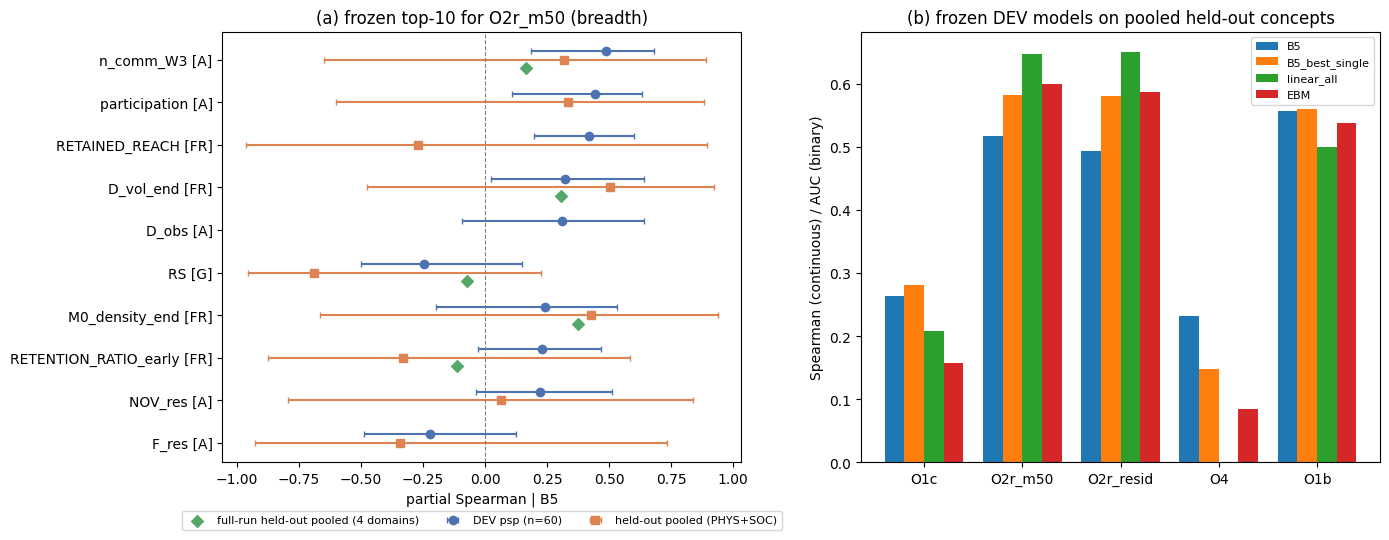

  outcome          model  n  metric  delta_vs_B5        delta_CI
      O1c             B5 40   0.264          NaN                
      O1c B5_best_single 40   0.281        0.017 [-0.113,+0.157]
      O1c     linear_all 40   0.208       -0.056 [-0.352,+0.268]
      O1c            EBM 40   0.158       -0.106 [-0.381,+0.197]
  O2r_m50             B5 40   0.518          NaN                
  O2r_m50 B5_best_single 40   0.582        0.064 [+0.010,+0.148]
  O2r_m50     linear_all 40   0.647        0.129 [+0.005,+0.296]
  O2r_m50            EBM 40   0.600        0.082 [-0.108,+0.333]
O2r_resid             B5 40   0.494          NaN                
O2r_resid B5_best_single 40   0.580        0.086 [+0.023,+0.150]
O2r_resid     linear_all 40   0.650        0.156 [+0.035,+0.307]
O2r_resid            EBM 40   0.588        0.094 [-0.108,+0.330]
       O4             B5 40   0.233          NaN                
       O4 B5_best_single 40   0.149       -0.084 [-0.191,+0.016]
       O4     linear_all 

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
# (a) forest: DEV est vs held-out pooled vs full-run pooled, O2r_m50 top-10
o = "O2r_m50" if "O2r_m50" in summary else list(summary)[0]
tb = result_table(o)
yy = np.arange(len(tb))[::-1]
ax = axes[0]
dev_ci = np.array([d["ci"] for d in spec["top10"][o]])
ax.errorbar(tb["DEV est"], yy + 0.2, xerr=[tb["DEV est"] - dev_ci[:, 0], dev_ci[:, 1] - tb["DEV est"]],
            fmt="o", color="#4C72B0", label=f"DEV psp (n={int(D[o].notna().sum())})", capsize=2)
pc = np.array([r["pooled_ci"] for r in summary[o] if r["in_top10"]])
ax.errorbar(tb["held-out pooled"], yy, xerr=[tb["held-out pooled"] - pc[:, 0], pc[:, 1] - tb["held-out pooled"]],
            fmt="s", color="#DD8452", label=f"held-out pooled ({'+'.join(HELD_GROUPS)})", capsize=2)
fr = pd.to_numeric(tb["full-run pooled"], errors="coerce")
ax.scatter(fr, yy - 0.2, marker="D", color="#55A868", label="full-run held-out pooled (4 domains)", zorder=3)
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_yticks(yy); ax.set_yticklabels([f"{a} [{b}]" for a, b in zip(tb.indicator, tb.family)])
ax.set_xlabel("partial Spearman | B5"); ax.set_title(f"(a) frozen top-{TOP_K} for {o} (breadth)")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

# (b) learned models vs B5 on pooled held-out
ax = axes[1]
outs = [o for o in learned_held if isinstance(learned_held[o].get("POOLED_HELDOUT", {}).get("B5"), dict)]
models = [m_ for m_ in ["B5", "B5_best_single", "linear_all", "EBM"]
          if any(m_ in learned_held[o]["POOLED_HELDOUT"] for o in outs)]
w = 0.2
for j, mname in enumerate(models):
    vals = [learned_held[o]["POOLED_HELDOUT"].get(mname, {}).get("metric", np.nan) for o in outs]
    ax.bar(np.arange(len(outs)) + (j - (len(models) - 1) / 2) * w, vals, w, label=mname)
ax.set_xticks(np.arange(len(outs))); ax.set_xticklabels(outs)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Spearman (continuous) / AUC (binary)")
ax.set_title("(b) frozen DEV models on pooled held-out concepts")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

rows = []
for o in outs:
    r = learned_held[o]["POOLED_HELDOUT"]
    for mname in models:
        if mname in r:
            rows.append({"outcome": o, "model": mname, "n": r["n"], "metric": r[mname]["metric"],
                         "delta_vs_B5": r[mname].get("delta_vs_B5"),
                         "delta_CI": (f"[{r[mname]['delta_ci'][0]:+.3f},{r[mname]['delta_ci'][1]:+.3f}]"
                                      if "delta_ci" in r[mname] else "")})
print(pd.DataFrame(rows).round(3).to_string(index=False))